In [ ]:
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "mother_folder"
rnn_folder = f"base_path/{date}_DL"

shap_number = "project_name"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [ ]:
import numpy as np

cnn_testX  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_detailed_test_features.npy")


date = "date2"
mixed_dataset = "project_name2"
testY  = np.load(f"{rnn_folder}/model_{mixed_dataset}/{date}_{mixed_dataset}_test_targets.npy")


print(cnn_testX.shape, testY.shape)

(384, 11, 67584) (384,)


In [ ]:

frames = 90 # frames per experiments
first_ex = 0
last_ex = 58
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 20.5
start_ave= 10
end_ave= 20
look_frame = 10     

In [4]:
# Ignore warning
import os
import tensorflow as tf
import logging
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)
tf.get_logger().setLevel('INFO')
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)

import numpy
#import pandas
import matplotlib.pyplot as plt
from scipy import io
from tensorflow.keras import layers, losses, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, ConvLSTM2D, Bidirectional
from sklearn.metrics import roc_curve
from sklearn.metrics import auc, roc_auc_score

In [5]:
# Allow grouth option of GPU
import tensorflow as tf
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)

In [6]:
# Clear session
from keras import backend as K
K.clear_session()

Using TensorFlow backend.


In [7]:
plt.rcParams["font.size"] = 18

In [8]:
# Data allocation from experiment No.
TRAIN = list(range(24))
VALID = list(range(8))
TEST  = list(range(8))

In [9]:
# Callback Setting
model_file_path = f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_best_model_{ver}.h5"

In [10]:
#input_train = cnn_trainX
#input_valid = cnn_validX
input_test  = cnn_testX

In [11]:
model = load_model(model_file_path)

In [12]:
#model = load_model("D:/Python_TK_3/datas/250422_RNN/shap01/250422_01_best_model_GRU.h5")

In [13]:
# Calcurate accuracy
model.evaluate(input_test,testY)

384/384 [==============================] - 1s 4ms/sample - loss: 0.3742 - acc: 0.8568


[0.37420569608608883, 0.8567708]

In [14]:
# Predict
#train_pred = model.predict(input_train)
#valid_pred = model.predict(input_valid)
test_pred = model.predict(input_test)

In [15]:
# Label
#train_target = trainY
#valid_target = validY
test_target = testY

In [16]:
prediction_frames = 24
print(prediction_frames)

24


In [ ]:

start_value = 0.0 + (look_frame/fs)

increment = 1/fs

count = prediction_frames

t = [start_value + i * increment for i in range(count)]

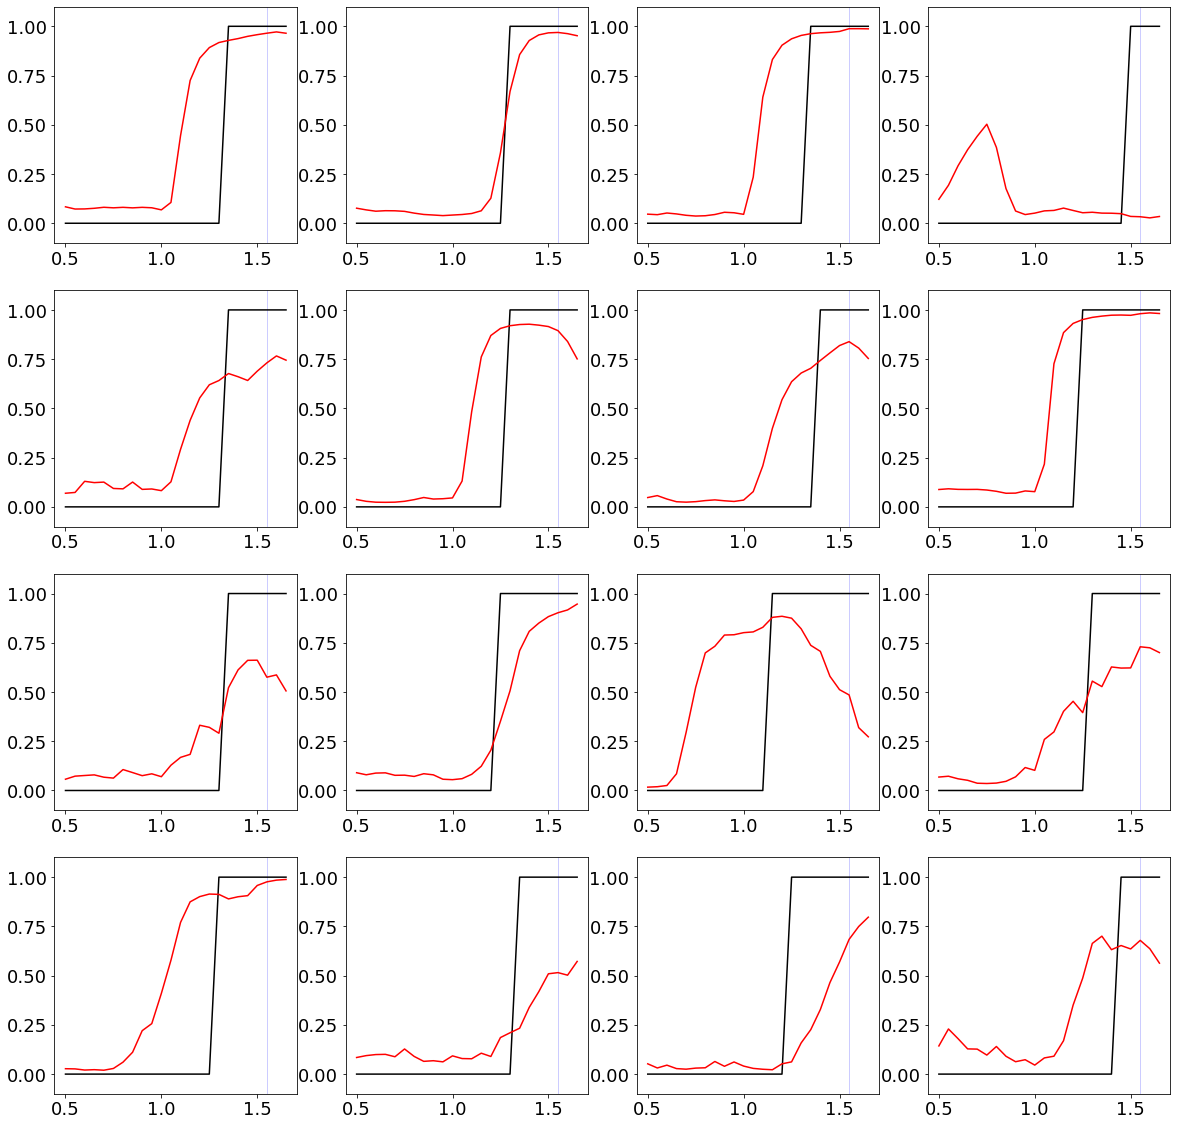

In [ ]:
plt.figure(figsize=(20, 20)) 

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, test_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [19]:
# Plot ROC curve
def plot_roc(y_pred, y_test, mode):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    AUC = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label="AUC = {:.3f}".format(AUC))
    plt.title(mode + " ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print('AUC: {:.3f}'.format(AUC))
    opt_thr = thresholds[numpy.argmax(tpr - fpr)]
    print('Optimal threshold: {:.3f}'.format(opt_thr))
    return fpr, tpr, opt_thr

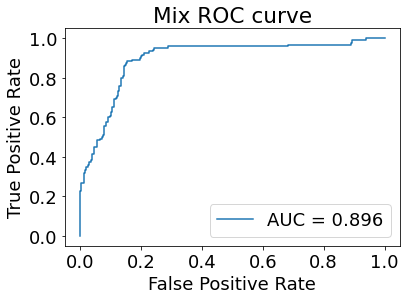

AUC: 0.896
Optimal threshold: 0.465


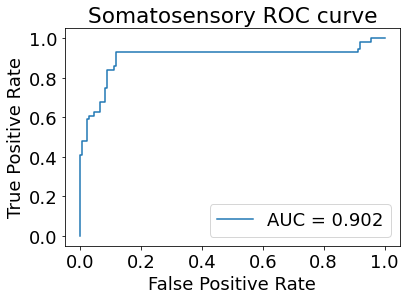

AUC: 0.902
Optimal threshold: 0.642


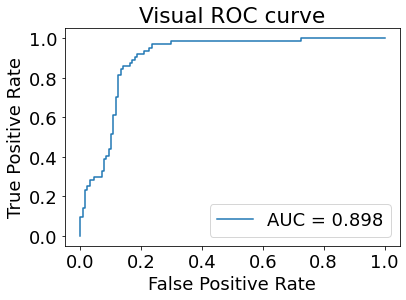

AUC: 0.898
Optimal threshold: 0.319


In [20]:
#train_fpr, train_tpr, train_thr = plot_roc(train_pred, train_target, "TRAINING")
#valid_fpr, valid_tpr, valid_thr = plot_roc(valid_pred, valid_target, "VALIDATION")
test_fpr_m, test_tpr_m, test_thr_m   = plot_roc(test_pred, test_target, "Mix")
test_fpr_s, test_tpr_s, test_thr_s   = plot_roc(test_pred[:int(test_pred.shape[0]/2)], test_target[:int(test_pred.shape[0]/2)], "Somatosensory")
test_fpr_v, test_tpr_v, test_thr_v   = plot_roc(test_pred[int(test_pred.shape[0]/2):], test_target[int(test_pred.shape[0]/2):], "Visual")

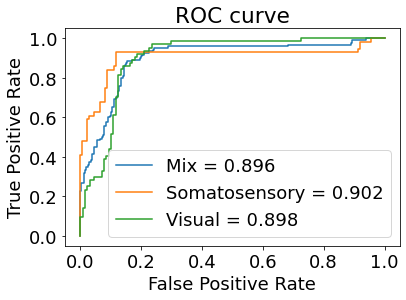

In [21]:
AUC = roc_auc_score(test_target, test_pred)
plt.plot(test_fpr_m, test_tpr_m, label="Mix = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target[:int(test_pred.shape[0]/2)], test_pred[:int(test_pred.shape[0]/2)])
plt.plot(test_fpr_s, test_tpr_s, label="Somatosensory = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target[int(test_pred.shape[0]/2):], test_pred[int(test_pred.shape[0]/2):])
plt.plot(test_fpr_v, test_tpr_v, label="Visual = {:.3f}".format(AUC))
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()